# Multimodal RAG — text + image retrieval over your document corpus

Built for Kaggle: real internet access (unlike the sandbox this was
prototyped in), so this version uses **sentence-transformers** for text
embeddings and **CLIP** for image embeddings + cross-modal text→image
retrieval — two purpose-built encoders instead of one shared workaround.

**Before running:** attach your document corpus as a Kaggle *Dataset* input
(Add Data on the right panel), and turn on a **GPU** accelerator
(Settings → Accelerator → GPU T4 x2 or similar) — embedding is much faster
on GPU and it's free on Kaggle.

Pipeline: `.pptx`/`.docx` → PDF (LibreOffice) → per-page text chunks + one
page-render image per page → embeddings → FAISS indices → query.


## 1. Install dependencies

In [1]:
# LibreOffice is needed to convert .pptx/.docx to .pdf so everything
# downstream can be handled uniformly by PyMuPDF.
!apt-get update -qq && apt-get install -y -qq libreoffice > /dev/null


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Extracting templates from packages: 100%


In [2]:
!pip install -q pymupdf python-pptx python-docx pillow \
    sentence-transformers open_clip_torch faiss-cpu


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 64.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 62.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00


## 2. Configuration

Point `DATA_DIR` at your uploaded dataset. Kaggle mounts datasets under
`/kaggle/input/<dataset-slug>/...` — this cell auto-detects the first
folder under `/kaggle/input/` if you don't set it explicitly, but check the
printed path is right before continuing.

In [11]:
import os
from pathlib import Path

DATA_DIR = Path("/kaggle/input/datasets/sujataramteke192110/rag-docs/RAG Docs") # <-- set this explicitly if auto-detect picks the wrong folder,
                  #     e.g. Path("/kaggle/input/rag-docs/RAG Docs")

if DATA_DIR is None:
    input_root = Path("/kaggle/input")
    candidates = [p for p in input_root.iterdir() if p.is_dir()] if input_root.exists() else []
    if not candidates:
        raise RuntimeError("No dataset found under /kaggle/input — attach your corpus as a Dataset first.")
    # walk one level further in case the dataset root wraps a single subfolder
    top = candidates[0]
    inner = [p for p in top.iterdir() if p.is_dir()]
    DATA_DIR = inner[0] if len(inner) == 1 and not any(top.glob("*.pdf")) and not any(top.glob("*.pptx")) else top

DATA_DIR = Path(DATA_DIR)
print("Using DATA_DIR =", DATA_DIR)
print("Sample contents:")
for p in list(DATA_DIR.rglob("*"))[:10]:
    print(" ", p)

WORK_DIR = Path("/kaggle/working")
CONV_DIR = WORK_DIR / "converted"
IMG_DIR = WORK_DIR / "extracted_images"
CONV_DIR.mkdir(exist_ok=True, parents=True)
IMG_DIR.mkdir(exist_ok=True, parents=True)

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Using DATA_DIR = /kaggle/input/datasets/sujataramteke192110/rag-docs/RAG Docs
Sample contents:
  /kaggle/input/datasets/sujataramteke192110/rag-docs/RAG Docs/Workbooks
  /kaggle/input/datasets/sujataramteke192110/rag-docs/RAG Docs/Worksheets and Exercises
  /kaggle/input/datasets/sujataramteke192110/rag-docs/RAG Docs/Training Materials
  /kaggle/input/datasets/sujataramteke192110/rag-docs/RAG Docs/Presentation materials
  /kaggle/input/datasets/sujataramteke192110/rag-docs/RAG Docs/Workbooks/Leaders
  /kaggle/input/datasets/sujataramteke192110/rag-docs/RAG Docs/Worksheets and Exercises/Self-awareness
  /kaggle/input/datasets/sujataramteke192110/rag-docs/RAG Docs/Worksheets and Exercises/Identifying Clear Goals
  /kaggle/input/datasets/sujataramteke192110/rag-docs/RAG Docs/Worksheets and Exercises/Seeking Feedback
  /kaggle/input/datasets/sujataramteke192110/rag-docs/RAG Docs/Worksheets and Exercises/Self-efficacy
  /kaggle/input/datasets/sujataramteke192110/rag-docs/RAG Docs/Worksheets

## 3. Convert `.pptx` / `.docx` to `.pdf`

In [12]:
import subprocess

def convert_to_pdf(path: Path, out_dir: Path):
    out_path = out_dir / (path.stem + ".pdf")
    if out_path.exists():
        return out_path
    result = subprocess.run(
        ["soffice", "--headless", "--convert-to", "pdf", "--outdir", str(out_dir), str(path)],
        capture_output=True, text=True, timeout=180
    )
    if result.returncode != 0:
        print(f"FAILED: {path.name} -> {result.stderr[:300]}")
        return None
    return out_path

office_files = list(DATA_DIR.rglob("*.pptx")) + list(DATA_DIR.rglob("*.docx"))
print(f"Converting {len(office_files)} pptx/docx files to PDF...")
for i, f in enumerate(office_files, 1):
    print(f"[{i}/{len(office_files)}] {f.name}")
    convert_to_pdf(f, CONV_DIR)
print("Done.")


Converting 16 pptx/docx files to PDF...
[1/16] Data Analytics Sample Report.pptx
[2/16] ResilienceBuilder Certification for Coaches Session 2 2025.pptx
[3/16] ResilienceBuilder Certification Session 1 Final 25.pptx
[4/16] ResilienceBuilder -Workshop and Team Results_V3,1.pptx
[5/16] ResilienceBuilder - Stress and Burnout in the Workplace for Leaders.pptx
[6/16] ResilienceBuilder -Social Support_V2.pptx
[7/16] ResilienceBuilder -Mental Strength_V12.pptx
[8/16] ResilienceBuilder -Emotional Intelligence_V8.pptx
[9/16] ResilienceBuilder -Physical Stamina_V5.pptx
[10/16] ResilienceBuilder -Purpose_V5.pptx
[11/16] ResilienceBuilder - Neuroscience and Extreme Stress.pptx
[12/16] ResilienceBuilder -Workshop and Team Results_V3.pptx
[13/16] Reframing Negative Thoughts - Worksheet 5.docx
[14/16] Stress v Performance Curve Stages in the report.docx
[15/16] Stress Management Indicator (SMI) Overview.docx
[16/16] ResilienceBuilder Certification Train the Trainer Guide.docx
Done.


## 4. Extract text chunks + page-render images

One render per page/slide (not per embedded object) — decks built from
design templates can inline thousands of decorative shapes as separate
embedded images; a full-page render is cheaper and a better retrieval unit
since it already contains any diagram/chart drawn on that page.

In [13]:
import re
import json
import fitz  # pymupdf

RENDER_DPI = 110
CHUNK_SIZE = 600
CHUNK_OVERLAP = 100

def collect_pdfs():
    originals = list(DATA_DIR.rglob("*.pdf"))
    orig_stems = {p.stem for p in originals}
    converted = [p for p in CONV_DIR.glob("*.pdf") if p.stem not in orig_stems]
    return originals + converted

def category_for(pdf_path: Path) -> str:
    try:
        rel = pdf_path.relative_to(DATA_DIR)
        parts = rel.parts[:-1]
        return "/".join(parts) if parts else "root"
    except ValueError:
        return "Converted (pptx/docx)"

def chunk_text(text, size=CHUNK_SIZE, overlap=CHUNK_OVERLAP):
    text = re.sub(r"\s+", " ", text).strip()
    if not text:
        return []
    chunks, start = [], 0
    while start < len(text):
        end = start + size
        chunks.append(text[start:end])
        start = end - overlap
        if start >= len(text) - overlap:
            break
    return [c for c in chunks if len(c.strip()) > 30]

def safe_stub(name: str) -> str:
    return re.sub(r"[^a-zA-Z0-9_-]+", "_", name)[:60]

pdfs = collect_pdfs()
print(f"Processing {len(pdfs)} PDFs...")

text_records, image_records = [], []
text_id = image_id = 0

for pi, pdf_path in enumerate(pdfs, 1):
    category = category_for(pdf_path)
    doc_name = pdf_path.stem
    stub = safe_stub(doc_name)
    try:
        doc = fitz.open(pdf_path)
    except Exception as e:
        print(f"  ! could not open {pdf_path}: {e}")
        continue

    if pi % 10 == 0 or pi == len(pdfs):
        print(f"[{pi}/{len(pdfs)}] {doc_name} ({doc.page_count} pages)")

    for page_index in range(doc.page_count):
        page = doc[page_index]
        page_num = page_index + 1

        for chunk in chunk_text(page.get_text()):
            text_records.append({
                "id": f"t{text_id}", "text": chunk, "source": doc_name,
                "page": page_num, "category": category,
            })
            text_id += 1

        try:
            pix = page.get_pixmap(dpi=RENDER_DPI)
            img_path = IMG_DIR / f"{stub}_p{page_num}_{image_id}.jpg"
            pix.save(img_path, jpg_quality=78)
            image_records.append({
                "id": f"i{image_id}", "image_path": str(img_path), "source": doc_name,
                "page": page_num, "category": category, "kind": "page_render",
            })
            image_id += 1
        except Exception as e:
            print(f"    ! render failed p{page_num}: {e}")

    doc.close()

with open(WORK_DIR / "text_chunks.jsonl", "w") as f:
    for r in text_records:
        f.write(json.dumps(r) + "\n")
with open(WORK_DIR / "images_manifest.jsonl", "w") as f:
    for r in image_records:
        f.write(json.dumps(r) + "\n")

print(f"\nDone. {len(text_records)} text chunks, {len(image_records)} images.")


Processing 101 PDFs...
[10/101] Values-based Decision Making - Worksheet (2 pages)
[20/101] Taking regular Exercise Worksheet (4 pages)
[30/101] Using the Ikigai Model for Self-Reflection - Worksheet (1 pages)
[40/101] Quality of Sleep Assessment_V2 (3 pages)
[50/101] Identifying and Managing your Stress Triggers - Worksheet (3 pages)
MuPDF error: syntax error: too many sub-functions in stitching function

MuPDF error: syntax error: too many sub-functions in stitching function

MuPDF error: syntax error: too many sub-functions in stitching function

MuPDF error: syntax error: too many sub-functions in stitching function

MuPDF error: syntax error: too many sub-functions in stitching function

MuPDF error: syntax error: too many sub-functions in stitching function

MuPDF error: syntax error: too many sub-functions in stitching function

MuPDF error: syntax error: too many sub-functions in stitching function

MuPDF error: syntax error: too many sub-functions in stitching function

MuPDF 

## 5. Build embeddings + FAISS indices

Two encoders:
- **sentence-transformers** (`all-MiniLM-L6-v2`) for text — better
  text-to-text semantic matching than CLIP's text tower, no 77-token limit.
- **CLIP** (`open_clip`, ViT-B-32) for images, and *also* for embedding the
  query when searching images — CLIP's text and image towers share a
  vector space, so a plain question can retrieve a relevant diagram
  directly.

Both auto-download from HuggingFace — fine on Kaggle with internet on.

In [14]:
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
import open_clip

# --- text encoder ---
text_model = SentenceTransformer("all-MiniLM-L6-v2", device=DEVICE)

# --- image + cross-modal encoder ---
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="laion2b_s34b_b79k"
)
clip_model = clip_model.to(DEVICE).eval()
clip_tokenizer = open_clip.get_tokenizer("ViT-B-32")

print("Models loaded on", DEVICE)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Models loaded on cpu


In [15]:
# --- embed text chunks ---
text_records = [json.loads(l) for l in open(WORK_DIR / "text_chunks.jsonl")]
texts = [r["text"] for r in text_records]

text_embeddings = text_model.encode(
    texts, batch_size=64, show_progress_bar=True, convert_to_numpy=True,
    normalize_embeddings=True,
).astype("float32")

text_index = faiss.IndexFlatIP(text_embeddings.shape[1])
text_index.add(text_embeddings)
faiss.write_index(text_index, str(WORK_DIR / "index_text.faiss"))

with open(WORK_DIR / "text_embed_meta.jsonl", "w") as f:
    for i, r in enumerate(text_records):
        r["row"] = i
        f.write(json.dumps(r) + "\n")

print(f"Text index: {text_index.ntotal} vectors, dim {text_embeddings.shape[1]}")


Batches:   0%|          | 0/31 [00:00<?, ?it/s]

Text index: 1931 vectors, dim 384


In [16]:
# --- embed page images ---
from PIL import Image
import torch

image_records = [json.loads(l) for l in open(WORK_DIR / "images_manifest.jsonl")]

all_embeddings, kept_records = [], []
batch_size = 64
with torch.no_grad():
    for i in range(0, len(image_records), batch_size):
        batch = image_records[i:i + batch_size]
        imgs, kept = [], []
        for r in batch:
            try:
                img = Image.open(r["image_path"]).convert("RGB")
                imgs.append(clip_preprocess(img))
                kept.append(r)
            except Exception as e:
                print(f"  ! skip {r['image_path']}: {e}")
        if not imgs:
            continue
        batch_tensor = torch.stack(imgs).to(DEVICE)
        feats = clip_model.encode_image(batch_tensor)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        all_embeddings.append(feats.cpu().numpy())
        kept_records.extend(kept)
        if i % (batch_size * 5) == 0:
            print(f"  image embed {i}/{len(image_records)}")

image_embeddings = np.vstack(all_embeddings).astype("float32")
image_index = faiss.IndexFlatIP(image_embeddings.shape[1])
image_index.add(image_embeddings)
faiss.write_index(image_index, str(WORK_DIR / "index_image.faiss"))

with open(WORK_DIR / "image_embed_meta.jsonl", "w") as f:
    for i, r in enumerate(kept_records):
        r["row"] = i
        f.write(json.dumps(r) + "\n")

print(f"Image index: {image_index.ntotal} vectors, dim {image_embeddings.shape[1]}")


  image embed 0/1185
  image embed 320/1185
  image embed 640/1185
  image embed 960/1185
Image index: 1185 vectors, dim 512


## 6. Query

In [17]:
def load_meta(path):
    return [json.loads(l) for l in open(path)]

def search(query, top_k=5):
    # text index: sentence-transformers query embedding
    t_qvec = text_model.encode([query], convert_to_numpy=True, normalize_embeddings=True).astype("float32")
    t_meta = load_meta(WORK_DIR / "text_embed_meta.jsonl")
    t_scores, t_idx = text_index.search(t_qvec, top_k)
    text_results = [
        {**t_meta[idx], "score": float(score)}
        for score, idx in zip(t_scores[0], t_idx[0]) if idx != -1
    ]

    # image index: CLIP text-tower query embedding (shared space with images)
    with torch.no_grad():
        tokens = clip_tokenizer([query]).to(DEVICE)
        i_qvec = clip_model.encode_text(tokens)
        i_qvec = (i_qvec / i_qvec.norm(dim=-1, keepdim=True)).cpu().numpy().astype("float32")
    i_meta = load_meta(WORK_DIR / "image_embed_meta.jsonl")
    i_scores, i_idx = image_index.search(i_qvec, top_k)
    image_results = [
        {**i_meta[idx], "score": float(score)}
        for score, idx in zip(i_scores[0], i_idx[0]) if idx != -1
    ]
    return text_results, image_results


def show_results(query, top_k=5):
    text_results, image_results = search(query, top_k)
    print(f"=== Query: {query!r} ===\n")
    print(f"--- Top {len(text_results)} TEXT matches ---")
    for r in text_results:
        print(f"[{r['score']:.3f}] {r['source']} (p.{r['page']}) [{r['category']}]")
        print(f"    {r['text'][:200]}")
    print(f"\n--- Top {len(image_results)} IMAGE matches ---")
    for r in image_results:
        print(f"[{r['score']:.3f}] {r['source']} (p.{r['page']}) [{r['category']}]")
        print(f"    {r['image_path']}")
    return text_results, image_results


In [18]:
# Try it — edit the query and re-run
text_results, image_results = show_results("how do I use the eisenhower matrix", top_k=5)


=== Query: 'how do I use the eisenhower matrix' ===

--- Top 5 TEXT matches ---
[0.666] ResilienceBuilder -Mental Strength_V12 (p.26) [Converted (pptx/docx)]
    The Eisenhower Matrix © 2025 S.H.C. Ltd. All rights reserved PRIORITISE USING THE EISENHOWER MATRIX PRIORITISATION | EXERCISE 1 • Break up your workload into tasks, including those that need to be don
[0.592] ResilienceBuilder -Mental Strength_V12 (p.43) [Converted (pptx/docx)]
    The Eisenhower Matrix © 2025 S.H.C. Ltd. All rights reserved USE THE EISENHOWER MATRIX TO CATEGORISE YOUR TASKS EXERCISE 1 • Break up your workload into tasks, including those that need to be done tod
[0.550] ResilienceBuilder -Mental Strength_V12 (p.40) [Converted (pptx/docx)]
    ic skills and can be delegated to someone else. Not Urgent and Not Important - Eliminate Includes tasks that don’t contribute to goals and waste time. Tools and techniques to help you stay on track wi
[0.503] ResilienceBuilder -Mental Strength_V12 (p.16) [Converted (pptx/

Top image match: ResilienceBuilder -Mental Strength_V12 page 26


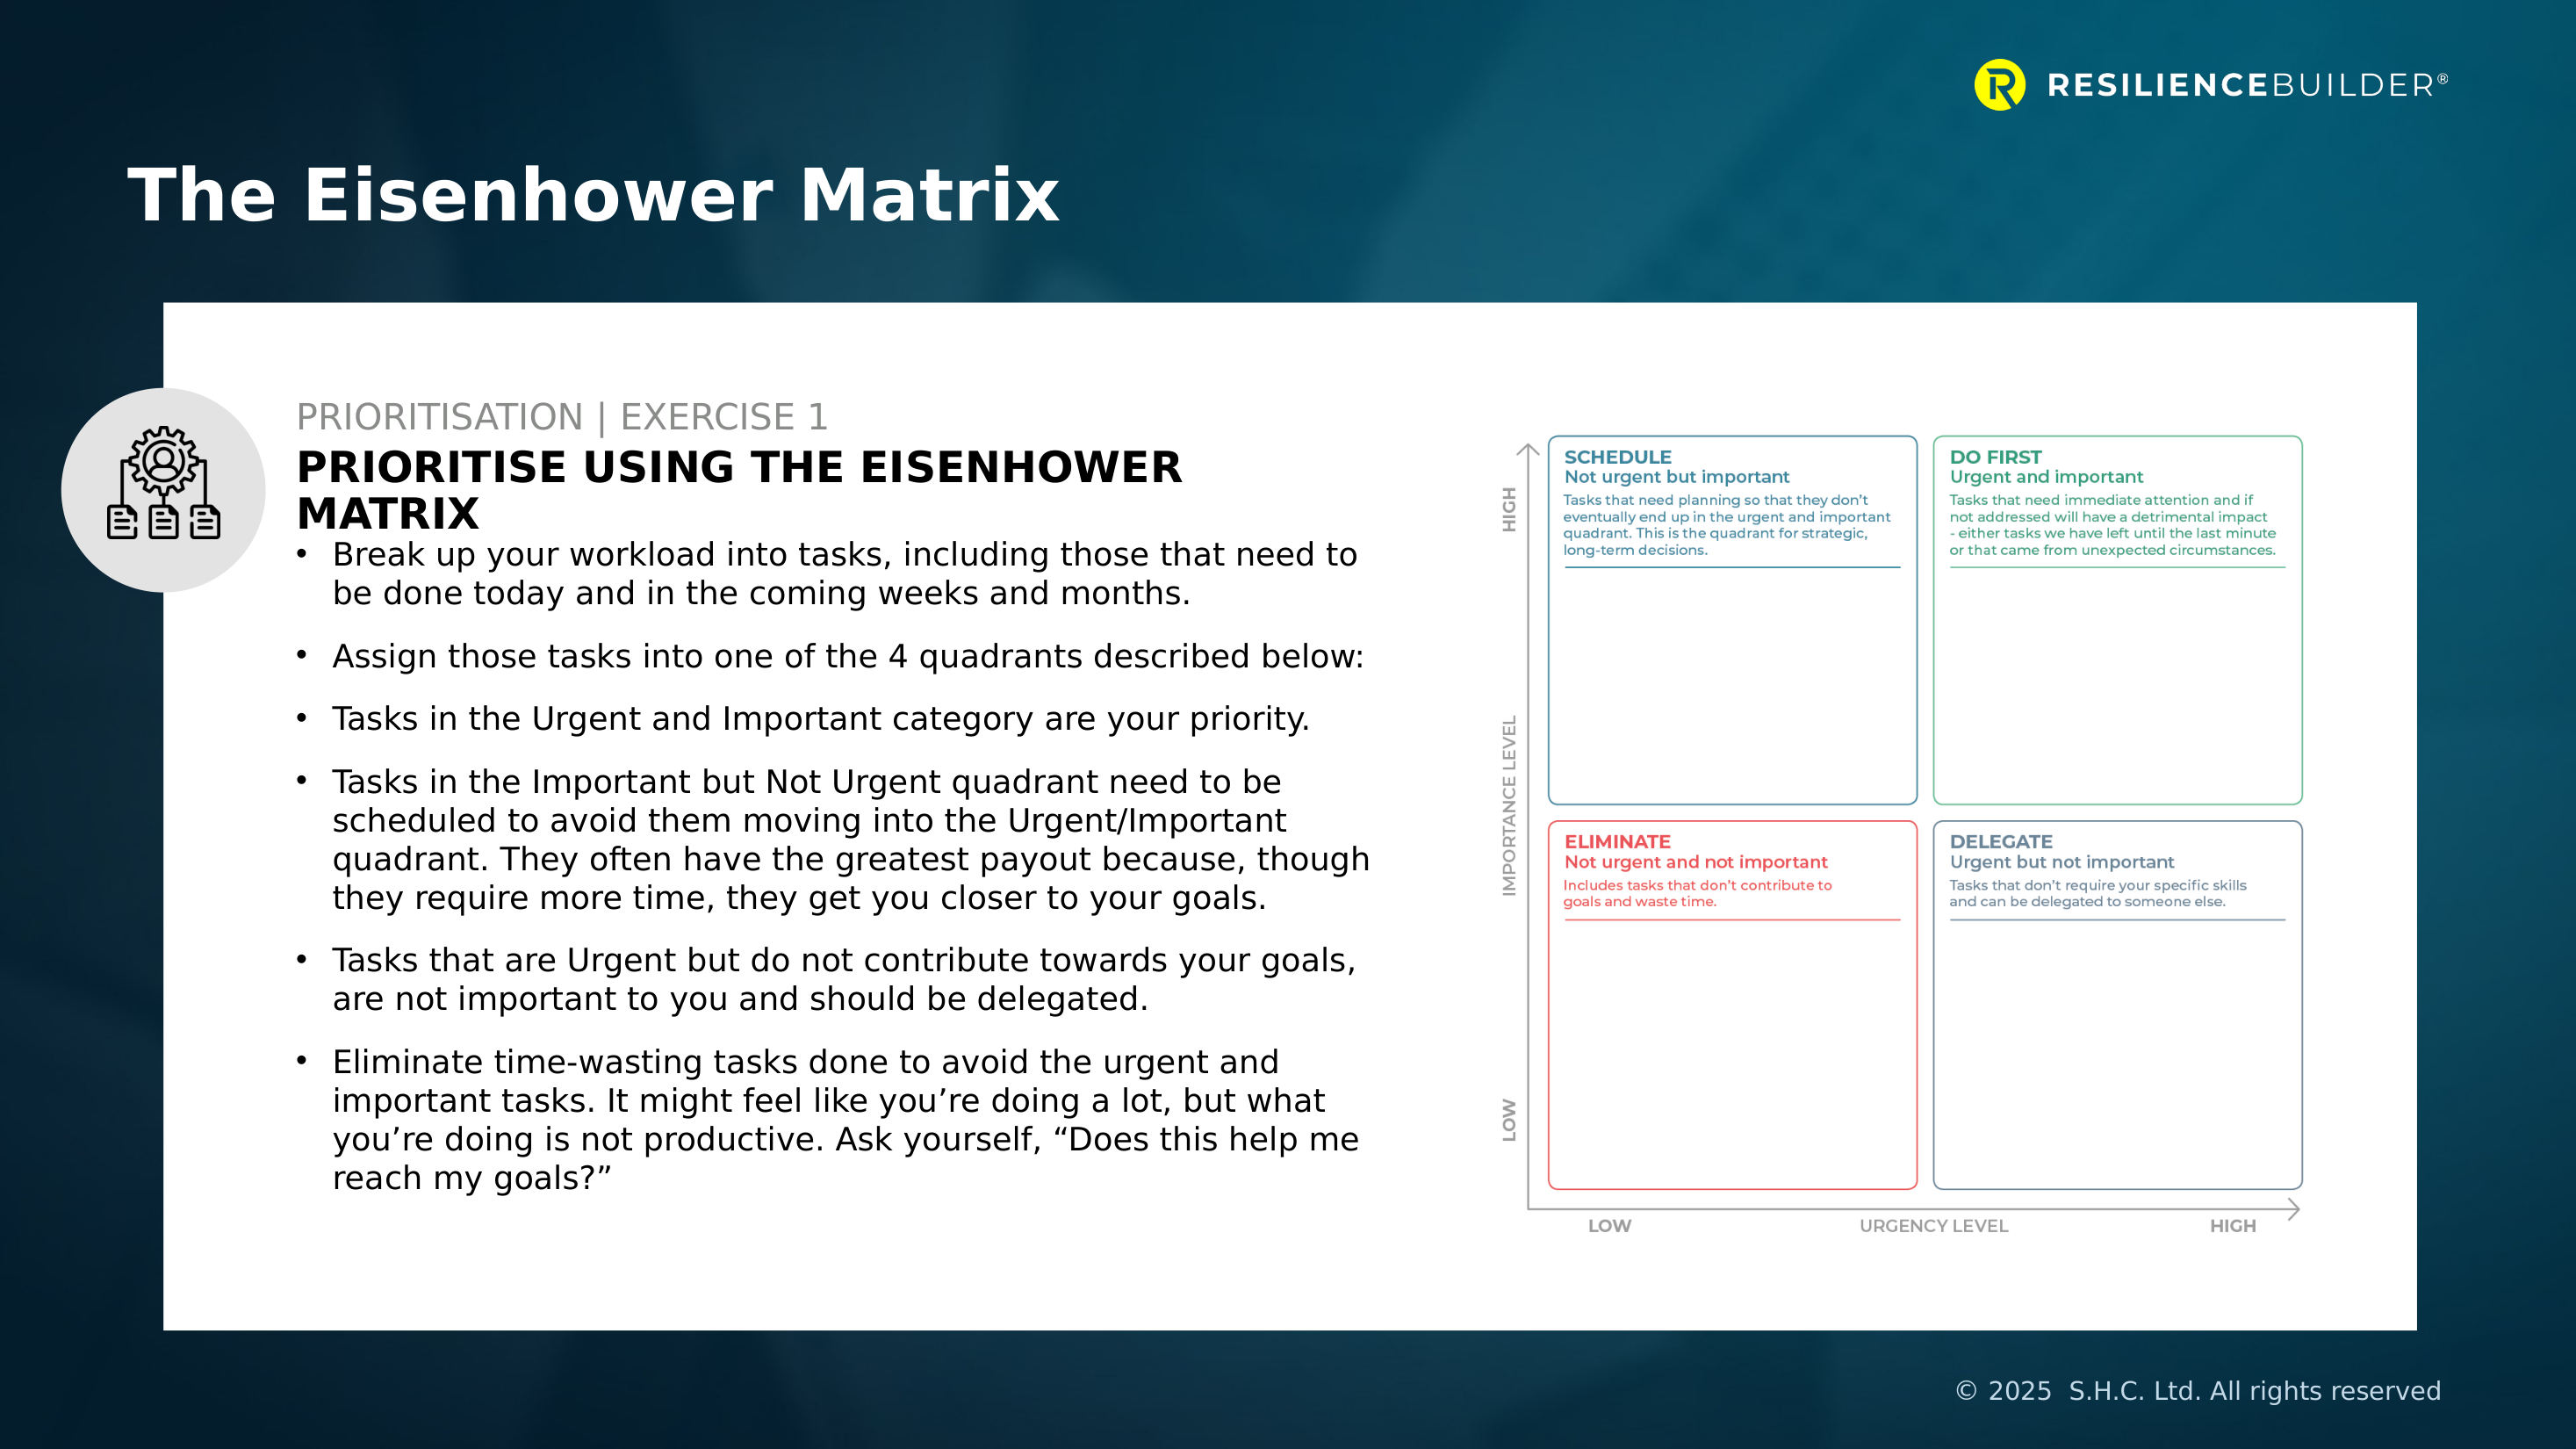

In [19]:
# Show the top image result inline
from IPython.display import Image as IPImage, display

if image_results:
    print("Top image match:", image_results[0]["source"], "page", image_results[0]["page"])
    display(IPImage(filename=image_results[0]["image_path"]))


## Next steps

- **Add a generation step**: feed the top text chunks (and, if using a
  vision-capable model, the top image files directly) as context to an LLM
  call to answer questions instead of just returning ranked passages.
- **OCR pass**: for graphic-heavy pages, OCR over the page renders would
  surface literal text-in-image content (axis labels, etc.) in the text
  index too.
- **Approximate index**: `IndexFlatIP` is exact and fine at a few thousand
  vectors; switch to `IndexIVFFlat` if this scales to tens of thousands of
  documents.
- **Persist outputs**: everything lands in `/kaggle/working/` — use
  "Save Version" to keep `index_text.faiss`, `index_image.faiss`, the
  `*_embed_meta.jsonl` files, and `extracted_images/` as notebook outputs
  so you don't have to re-run extraction/embedding every session.
